In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization, Add, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore", category = FutureWarning)

In [2]:
# === CREAZIONE DATASET PER TRAINING (5% DATI DI OGNUNO DEI 15 SOGGETTI) ===

import pandas as pd
from sklearn.model_selection import train_test_split

file_list = [
    "PSD_dataset_Bergantin_Fulvio_42.csv",
    "PSD_dataset_Cambareri_Chiara_26.csv",
    "PSD_dataset_Capria_Francesco_26.csv",
    "PSD_dataset_Capria_Alessandro_19.csv",
    "PSD_dataset_Cicirelli_Franco_50.csv",
    "PSD_dataset_Coppolillo_Erica_25.csv",
    "PSD_dataset_Damore_Francesco_45.csv",
    "PSD_dataset_DeMaio_Annarita_34.csv",
    "PSD_dataset_Falcone_Alberto_40.csv",
    "PSD_dataset_Folino_Gianluigi_52.csv",
    "PSD_dataset_Guarascio_Massimo_42.csv",
    "PSD_dataset_Guerrieri_Antonio_42.csv",
    "PSD_dataset_Islam_Md_Babul.csv",
    "PSD_dataset_Khan_Irfanullah_33.csv",
    "PSD_dataset_Macrì_Davide_44.csv"
]

subset_list = []

for file in file_list:
    df = pd.read_csv(file)
    
    # Separazione feature e target
    X = df.drop("Event Id", axis=1)
    y = df["Event Id"]

    # Estrazione 5% dei dati con stratify e shuffle
    _, X_subset, _, y_subset = train_test_split(
        X, y, test_size=0.05, stratify=y, shuffle=True, random_state=42
    )

    df_subset = pd.DataFrame(X_subset)
    df_subset["Event Id"] = y_subset.values
    subset_list.append(df_subset)

# Unione dei subset
combined_subset = pd.concat(subset_list, ignore_index=True)

# Salvataggio in CSV
combined_subset.to_csv("PSD_dataset_15_5%.csv", index=False)


In [3]:
# === CARICAMENTO DEL DATASET PER TRAINING ===

#psd_df = pd.read_csv("PSD_dataset_15.csv")
psd_df = pd.read_csv("PSD_dataset_15_5%.csv")

In [4]:
# === SPLIT DATASET ===

# === SPLIT ORIGINALE ===
X = psd_df.drop("Event Id", axis=1).astype(float)
y = psd_df["Event Id"]  # Nessun fillna necessario, lo hai già fatto



# Normalizzazione globale 
#X_scaled = preprocessing.StandardScaler().fit_transform(X)

# Split stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, shuffle=True, random_state=42, stratify=y    #se normalizzo tra zero e uno uso x_scaled_minmax, altrimenti x_scaled
)

# Normalizzazione tra 0 e 1
scaler = MinMaxScaler()
X_scaled_minmax = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

# === COSTRUZIONE DATAFRAME PER IL TRAINING SET ===
train_df = pd.DataFrame(X_scaled_minmax)
train_df["Event Id"] = y_train.values


### ---UNDERSAMPLING CLASSE PIù FREQUENTE---
# Suddivisione per classi
df_0 = train_df[train_df["Event Id"] == 0.0]
df_others = train_df[train_df["Event Id"] != 0.0]

# Sottocampionamento classe 0.0
n_samples = int(df_others["Event Id"].value_counts().mean())
df_0_downsampled = resample(df_0, replace=False, n_samples=n_samples, random_state=42)

# Ricombinazione e shuffle
df_train_balanced_US = pd.concat([df_0_downsampled, df_others])
df_train_balanced_US = df_train_balanced_US.sample(frac=1, random_state=42)

# Recupero X e y bilanciati
X_train_balanced_US = df_train_balanced_US.drop("Event Id", axis=1).values
y_train_balanced_US = df_train_balanced_US["Event Id"].values


### ---OVERSAPLING CLASSI MINORITARIE---

# Trova la classe più numerosa
class_counts = train_df["Event Id"].value_counts()
max_samples = class_counts.max()

# Oversampling di tutte le classi (tranne quella già con più esempi)
balanced_dfs = []
for cls, count in class_counts.items():
    df_cls = train_df[train_df["Event Id"] == cls]
    if count < max_samples:
        df_upsampled = resample(df_cls, replace=True, n_samples=max_samples, random_state=42)
    else:
        df_upsampled = df_cls
    balanced_dfs.append(df_upsampled)

# Ricombinazione e shuffle
df_train_balanced_OS = pd.concat(balanced_dfs)
df_train_balanced_OS = df_train_balanced_OS.sample(frac=1, random_state=42)

# Recupero X e y bilanciati
X_train_balanced_OS = df_train_balanced_OS.drop("Event Id", axis=1).values
y_train_balanced_OS = df_train_balanced_OS["Event Id"].values



In [5]:
### --- RESIDUAL NETWORK --- ###

from tensorflow.keras.layers import GaussianNoise

# === CALLBACKS ===
checkpoint = ModelCheckpoint(
    filepath="best_m_15.weights.h5",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=0
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)

callbacks_list = [checkpoint, reduce_lr]

# === PREPARAZIONE ONE-HOT ENCODING ===
classes = np.sort(np.unique(np.concatenate([y_train_balanced_OS, y_test])))
to_index = {c: i for i, c in enumerate(classes)}

y_train_cat = to_categorical([to_index[c] for c in y_train_balanced_OS],
                             num_classes=len(classes))
y_test_cat = to_categorical([to_index[c] for c in y_test],
                            num_classes=len(classes))

### --- CALCOLO DEI PESI --- ###
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_balanced_OS),
    y=y_train_balanced_OS
)

class_weights = dict(zip(np.unique(y_train), class_weights_array))

for cls, weight in class_weights.items():
    print(f"Classe {int(cls)}: peso {weight:.2f}")

# === COSTRUZIONE MODELLO MLP ===

def create_residual(input_layer, factors, dropout_pcg):
    out = Dense(factors, activation="relu")(input_layer)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)

    out = Add()([out, input_layer])

    out = Dense(factors, activation="relu")(out)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)
    
    return out

def create_dnn_tf_func(dimensions, factors=256):
    dropout_pcg = 0.25
    
    input_layer = Input(shape=(dimensions,))
    
    #noisy_input = GaussianNoise(0.1)(input_layer)         #con Rumore Bianco
    #out = Dense(factors, activation="relu")(noisy_input)   #con Rumore Bianco
    
    out = Dense(factors, activation="relu")(input_layer)    #senza Rumore Bianco
    
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)

    out_1 = create_residual(out, factors, dropout_pcg)
    
    out = Concatenate()([out_1, input_layer])

    out = Dense(len(classes), activation='softmax')(out)

    model = Model(inputs=[input_layer], outputs=out)

    opt = tf.keras.optimizers.RMSprop(learning_rate=0.001, epsilon=1e-14)

    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    return model, input_layer, out

# === CREAZIONE MODELLO ===
model_init = create_dnn_tf_func(len(X_scaled_minmax[0]))
model = model_init[0]
model_input = model_init[1]
model_output = model_init[2]


Classe 0: peso 1.00
Classe 33024: peso 1.00
Classe 33025: peso 1.00
Classe 33026: peso 1.00
Classe 33027: peso 1.00


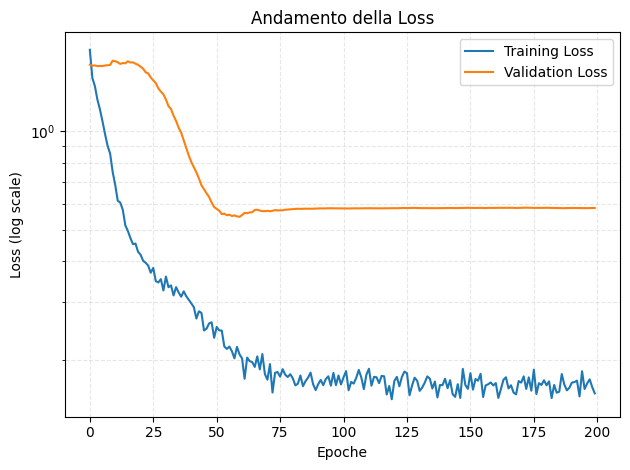

In [6]:
TRAIN_MODEL = True  # Cambia in False dopo il primo addestramento

if TRAIN_MODEL:
    history = model.fit(
        X_train_balanced_OS,
        y_train_cat,
        validation_split=0.2,
        epochs=200,
        batch_size=128,
        callbacks=callbacks_list,
        verbose=0
    )
    model.save_weights("best_m_15.weights.h5")

    # Plot delle curve di loss solo se alleni
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Andamento della Loss')
    plt.yscale('log')
    plt.xlabel('Epoche')
    plt.ylabel('Loss (log scale)')
    plt.grid(True, which='both', ls='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [7]:
'''# === CARICAMENTO NUOVO DATASET DI TEST ===
# Caricamento Dataset Nuovo Soggetto SENZA FineTune
psd_df_test = pd.read_csv("PSD_dataset_Mariani_Luca_33.csv")  # Cambia il nome del file

X_test = psd_df_test.drop("Event Id", axis=1).astype(float)
y_test = psd_df_test["Event Id"]

# Normalizzazione separata per il soggetto di test
X_scaled_test = scaler.fit_transform(X_test)


# One-hot e classi aggiornate
classes = np.sort(np.unique(np.concatenate([y_train_balanced_OS, y_test])))
to_index = {c: i for i, c in enumerate(classes)}
y_test_cat = to_categorical([to_index[c] for c in y_test], num_classes=len(classes))

# Carica i pesi addestrati
model.load_weights("best_m_15.weights.h5")

# === PREDIZIONE ===
y_hat_nn = model.predict(X_scaled_test)
y_hat_nn_labels = classes[np.argmax(y_hat_nn, axis=1)]
y_actu_nn = pd.Series(y_test, name='Actual')
df_confusion_nn = pd.crosstab(y_actu_nn, y_hat_nn_labels)

# === VALUTAZIONE ===
acc_nn = accuracy_score(y_test, y_hat_nn_labels)
print("Model Accuracy (Neural Network): %.2f" % acc_nn)
print(df_confusion_nn)
print(classification_report(y_test, y_hat_nn_labels))
'''

'# === CARICAMENTO NUOVO DATASET DI TEST ===\n# Caricamento Dataset Nuovo Soggetto SENZA FineTune\npsd_df_test = pd.read_csv("PSD_dataset_Mariani_Luca_33.csv")  # Cambia il nome del file\n\nX_test = psd_df_test.drop("Event Id", axis=1).astype(float)\ny_test = psd_df_test["Event Id"]\n\n# Normalizzazione separata per il soggetto di test\nX_scaled_test = scaler.fit_transform(X_test)\n\n\n# One-hot e classi aggiornate\nclasses = np.sort(np.unique(np.concatenate([y_train_balanced_OS, y_test])))\nto_index = {c: i for i, c in enumerate(classes)}\ny_test_cat = to_categorical([to_index[c] for c in y_test], num_classes=len(classes))\n\n# Carica i pesi addestrati\nmodel.load_weights("best_m_15.weights.h5")\n\n# === PREDIZIONE ===\ny_hat_nn = model.predict(X_scaled_test)\ny_hat_nn_labels = classes[np.argmax(y_hat_nn, axis=1)]\ny_actu_nn = pd.Series(y_test, name=\'Actual\')\ndf_confusion_nn = pd.crosstab(y_actu_nn, y_hat_nn_labels)\n\n# === VALUTAZIONE ===\nacc_nn = accuracy_score(y_test, y_hat_nn

In [21]:
# === CARICAMENTO NUOVO SOGGETTO ===
# con FineTune e Bilanciamento Test (Oversampling)


psd_df_test = pd.read_csv("PSD_dataset_Zicari_Paolo_51.csv")

X_new = psd_df_test.drop("Event Id", axis=1).astype(float)
y_new = psd_df_test["Event Id"]

# Normalizzazione con lo stesso scaler del training
X_scaled_new = scaler.transform(X_new)

# Split 10% (adattamento) + 90% (test)
from sklearn.model_selection import train_test_split

X_fine_tune, X_final_test, y_fine_tune, y_final_test = train_test_split(
    X_scaled_new, y_new, train_size=0.20, shuffle=True, stratify=y_new, random_state=42
)

# === BILANCIAMENTO 10% PER FINE-TUNING (OVERSAMPLING) ===
from sklearn.utils import resample

df_finetune = pd.DataFrame(X_fine_tune)
df_finetune["Event Id"] = y_fine_tune.values

max_samples = df_finetune["Event Id"].value_counts().max()

balanced_finetune = []
for cls, count in df_finetune["Event Id"].value_counts().items():
    df_cls = df_finetune[df_finetune["Event Id"] == cls]
    if count < max_samples:
        df_upsampled = resample(df_cls, replace=True, n_samples=max_samples, random_state=42)
    else:
        df_upsampled = df_cls
    balanced_finetune.append(df_upsampled)

df_finetune_balanced = pd.concat(balanced_finetune).sample(frac=1, random_state=42)

X_fine_tune = df_finetune_balanced.drop("Event Id", axis=1).values
y_fine_tune = df_finetune_balanced["Event Id"].values

# === One-hot encoding ===
classes = np.sort(np.unique(np.concatenate([y_train_balanced_OS, y_new])))
to_index = {c: i for i, c in enumerate(classes)}

y_fine_tune_cat = to_categorical([to_index[c] for c in y_fine_tune], num_classes=len(classes))
y_final_test_cat = to_categorical([to_index[c] for c in y_final_test], num_classes=len(classes))

# === Ricarica i pesi pre-addestrati ===


# Ricompila il modello con learning rate più basso per il fine-tuning
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)


model.load_weights("best_m_15.weights.h5")


# === CALLBACKS ===
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_finetune = ModelCheckpoint(
    filepath="best_finetune.weights.h5",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=0
)

reduce_lr_finetune = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_finetune = [early_stop, checkpoint_finetune, reduce_lr_finetune]

# === MINI-TRAINING SU 10% DEL NUOVO SOGGETTO ===
model.fit(
    X_fine_tune,
    y_fine_tune_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    verbose=0,
    callbacks=callbacks_finetune
)

# === PREDIZIONE SUL 90% RESTANTE ===
y_pred_prob = model.predict(X_final_test)
y_pred = classes[np.argmax(y_pred_prob, axis=1)]

# === VALUTAZIONE ===
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(y_final_test, y_pred)
print(f"Model Accuracy on New Subject (90% test after 10% fine-tuning): {acc:.2f}")

# Confusion matrix e classificazione
import pandas as pd

y_true_series = pd.Series(y_final_test, name="Actual")
y_pred_series = pd.Series(y_pred, name="Predicted")
df_confusion = pd.crosstab(y_true_series, y_pred_series)
print(df_confusion)
print("\nClassification Report:\n")
print(classification_report(y_final_test, y_pred))


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Model Accuracy on New Subject (90% test after 10% fine-tuning): 0.40
Predicted  0.0      33024.0  33025.0  33026.0  33027.0
Actual                                                
0.0            102      102       83       58       64
33024.0         25       39       36       15       24
33025.0         43       41       30       18       23
33026.0         41       37       21       15       21
33027.0         34       27       38       25       33

Classification Report:

              precision    recall  f1-score   support

         0.0       0.58      0.35      0.43       512
     33024.0       0.27      0.46      0.34       179
     33025.0       0.38      0.55      0.45       179
     33026.0       0.40      0.38      0.39       180
     33027.0       0.35      0.39      0.37       179

    accuracy                           0.40      1229
   macro avg       0.40      0.43      0.40      1229
weighted avg       0.45      0.40      0.41     